# Lab 5 — Ensemble the Churn Model
**SDA-AIE-111 · Day 3 · Hour 5 · 50 minutes · pairs**

**Objective.** Beat the logistic champion with forest and XGBoost **under the shared harness**; produce permutation importance and one partial-dependence reading; update the champion/challenger table with an argued recommendation.


In [1]:
# --- Course setup (identical in every lab) -----------------------------------
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

def find_repo_root() -> Path:
    """Locate the course repo root by looking for data/manafeth_customers.parquet."""
    for cand in [Path.cwd(), *Path.cwd().parents]:
        if (cand / "data" / "manafeth_customers.parquet").exists():
            return cand
    raise FileNotFoundError(
        "Course data not found — copy the Manafeth data package files into <repo>/data/")

ROOT = find_repo_root()
DATA = ROOT / "data"
sys.path.insert(0, str(ROOT / "src"))
print("repo root:", ROOT)

repo root: /home/claude/amlf/repo


In [2]:
from sklearn.model_selection import train_test_split
from manafeth.features import (build_preprocessor, build_feature_table,
                               MODEL_NUM_COLS, CAT_COLS, LEAKY)
from manafeth.evaluation import CV, evaluate, recall_at_budget, precision_at_budget

customers = pd.read_parquet(DATA / "manafeth_customers.parquet")
orders = pd.read_parquet(DATA / "manafeth_orders.parquet")
full = build_feature_table(customers, orders, pd.Timestamp("2025-11-01"))

X_all = full.drop(columns=["churned_30d", "customer_id", *LEAKY])
y_all = full["churned_30d"]
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.20, stratify=y_all, random_state=RANDOM_STATE)
print("train:", X_train.shape, "| churn:", round(y_train.mean(), 3))

train: (38400, 22) | churn: 0.14


## Task 1 — Random forest: strong defaults, honest OOB *(10 min)*

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

def make_pipe(model):
    return Pipeline([("prep", build_preprocessor(MODEL_NUM_COLS, CAT_COLS)), ("clf", model)])

forest = make_pipe(RandomForestClassifier(
    n_estimators=300, max_features="sqrt", min_samples_leaf=5,
    class_weight="balanced", oob_score=True, n_jobs=-1, random_state=RANDOM_STATE))
res_forest = evaluate(forest, X_train, y_train, "random_forest")
print(res_forest[["pr_auc_mean", "pr_auc_std"]])
forest.fit(X_train, y_train)
print("OOB accuracy cross-check:", round(forest["clf"].oob_score_, 3))

pr_auc_mean    0.561
pr_auc_std     0.007
Name: random_forest, dtype: float64


OOB accuracy cross-check: 0.862


## Task 2 — XGBoost with early stopping *(15 min)*

Low learning rate; let early stopping choose the length. The eval set is carved from **train** and kept apart from reported-score folds — reported scores still come from the shared harness.


In [4]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split as tts

X_fit, X_es, y_fit, y_es = tts(X_train, y_train, test_size=0.15,
                               stratify=y_train, random_state=RANDOM_STATE)
prep = build_preprocessor(MODEL_NUM_COLS, CAT_COLS).fit(X_fit)   # explicit for eval_set API

spw = (y_fit == 0).sum() / (y_fit == 1).sum()
xgb_probe = XGBClassifier(
    n_estimators=2000,                # ceiling — early stopping finds the real number
    learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw, eval_metric="aucpr",
    early_stopping_rounds=50, random_state=RANDOM_STATE, n_jobs=-1)
xgb_probe.fit(prep.transform(X_fit), y_fit,
              eval_set=[(prep.transform(X_es), y_es)], verbose=False)
print("best_iteration:", xgb_probe.best_iteration, " -> n_estimators, observed not guessed")

# Reported score comes from the shared harness (pipeline form, fixed length):
xgb_pipe = make_pipe(XGBClassifier(
    n_estimators=max(xgb_probe.best_iteration, 50), learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=round(spw, 1),
    eval_metric="aucpr", random_state=RANDOM_STATE, n_jobs=-1))
res_xgb = evaluate(xgb_pipe, X_train, y_train, "xgboost")
print(res_xgb[["pr_auc_mean", "pr_auc_std"]], "\n<- same harness, so the comparison is legal")

best_iteration: 337  -> n_estimators, observed not guessed


pr_auc_mean    0.575
pr_auc_std     0.008
Name: xgboost, dtype: float64 
<- same harness, so the comparison is legal


## Task 3 — n_estimators: a flattening, not a peak *(5 min)*

In [5]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

curves = {}
for n in [50, 100, 300, 600]:
    f = make_pipe(RandomForestClassifier(n_estimators=n, max_features="sqrt",
                                         min_samples_leaf=5, class_weight="balanced",
                                         n_jobs=-1, random_state=RANDOM_STATE))
    curves[n] = cross_val_score(f, X_train, y_train, cv=3,
                                scoring="average_precision", n_jobs=1).mean()
print(pd.Series(curves).round(4))
print("More trees never overfit a forest — they just stop helping. Buy compute wisely.")

50     0.5454
100    0.5493
300    0.5514
600    0.5531
dtype: float64
More trees never overfit a forest — they just stop helping. Buy compute wisely.


## Task 4 — Permutation importance vs impurity *(10 min)*

Teach the flaw before the tool: impurity importances inflate high-cardinality/continuous features. Permutation importance on held-out data is the honest reading — and a leakage detector (a feature that dominates suspiciously is a suspect).


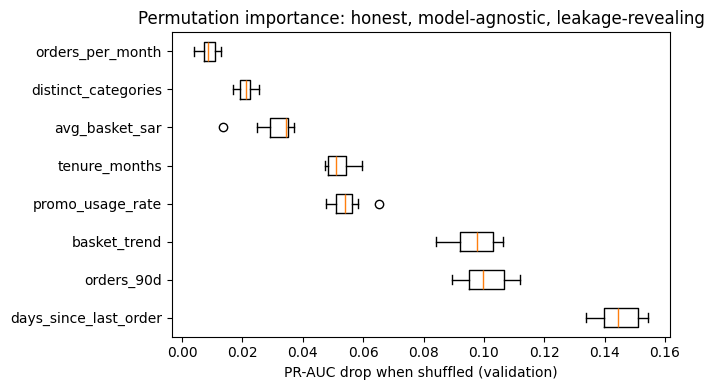

days_since_last_order    0.1445
orders_90d               0.1004
basket_trend             0.0968
promo_usage_rate         0.0543
tenure_months            0.0519
avg_basket_sar           0.0311
distinct_categories      0.0212
orders_per_month         0.0088
dtype: float64


In [6]:
from sklearn.inspection import permutation_importance

xgb_pipe.fit(X_fit, y_fit)
imp = permutation_importance(xgb_pipe, X_es, y_es, scoring="average_precision",
                             n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
order = imp.importances_mean.argsort()[::-1][:8]
fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot(imp.importances[order].T, tick_labels=X_es.columns[order], vert=False)
ax.set_xlabel("PR-AUC drop when shuffled (validation)")
ax.set_title("Permutation importance: honest, model-agnostic, leakage-revealing")
plt.tight_layout(); plt.show()
print(pd.Series(imp.importances_mean[order].round(4), index=X_es.columns[order]))

## Task 5 — Partial dependence: the curve the CRM team can act on *(5 min)*

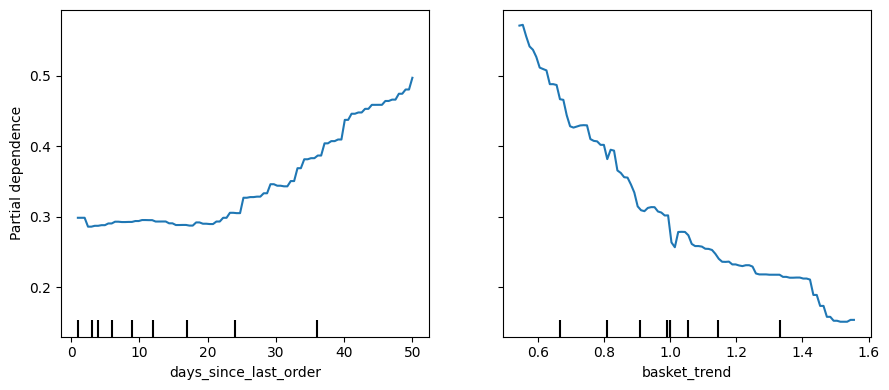

In [7]:
from sklearn.inspection import PartialDependenceDisplay

# (cast integer columns to float — PDP builds a float grid over each feature)
X_pd = X_es.copy()
for c in X_pd.select_dtypes("integer").columns:
    X_pd[c] = X_pd[c].astype(float)

fig, ax = plt.subplots(figsize=(9, 4))
PartialDependenceDisplay.from_estimator(
    xgb_pipe, X_pd, ["days_since_last_order", "basket_trend"], kind="average", ax=ax)
plt.tight_layout(); plt.show()
# Reading: churn risk accelerates sharply after ~18 quiet days —
# the old 21-day heuristic was nearly right; the model refines it per-customer.

## Task 6 — Champion, challenger *(5 min)*

Update `project/CHAMPION.md`: the harness table (all models, same folds), your recommendation, and the challenger-retention sentence (the interpretable logistic stays in the room — it is the sanity check and the fallback).

| model | PR-AUC (mean ± std) | recall@20% |
|---|---|---|
| dummy | | |
| logreg+features | | |
| tree(depth=6) | | |
| random_forest | | |
| **xgboost** | | |

**Commit:** `feat(lab5): ensembles under shared harness; champion argued`
